# Omega60 laser sampling

In [1]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 
import math

from helpers import coord
from helpers import geometry
from helpers import sampler


# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "coord"
        id  theta_deg     phi_deg             X         Y         Z color
0  Beam_01  11.640723   90.000000  2.038592e-17  0.332927  1.616063  blue
1  Beam_02  11.640723  270.000000 -6.115775e-17 -0.332927  1.616063  blue
2  Beam_03  31.270210   51.026553  5.386876e-01  0.665855  1.410303  blue
3  Beam_04  31.270210  128.973447 -5.386876e-01  0.665855  1.410303  blue
4  Beam_05  31.270210  231.026553 -5.386876e-01 -0.665855  1.410303  blue
60
# Module 'sampler' loaded successfully.


# Module omega geometry loaded (Author: Clara Jourdan)


## Support functions

### Sample of random laser points in a 2D window distribution normale

### Use of normal distribution in the sample of points 

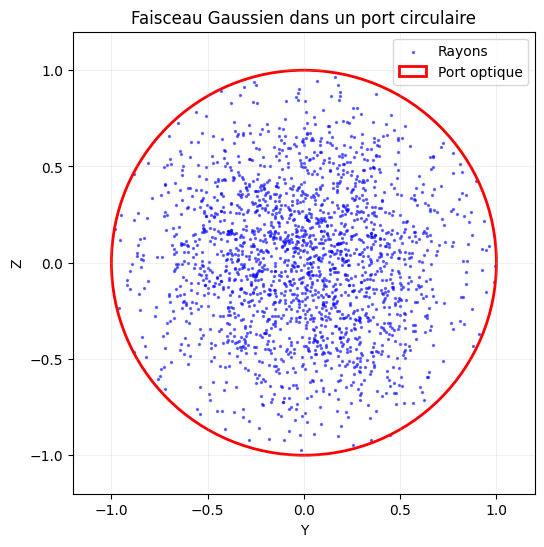

In [2]:


# --- Paramètres ---
radius = 1.0
c = np.array([0., 0., 0.]) # Centre
# t1 et t2 définissent le plan du cercle (ici YZ)
t1, t2 = np.array([0, 1, 0]), np.array([0, 0, 1])

# Distribution Gaussienne (concentrée au centre)
dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.4).rvs(size=(n, 2))

# --- Génération ---
# On utilise l1=2*radius et l2=2*radius car ta fonction utilise l1/2 comme rayon
xs = sampler.sample_window(
    t1, 
    t2, 
    l1=2*radius, 
    l2=2*radius, 
    center=c, 
    num_points=2000, 
    dist=dist_gauss
)

# --- Tracé ---
fig, ax = plt.subplots(figsize=(6,6))

# Tracé des points (Axe Y et Axe Z)
ax.scatter(xs[:,1], xs[:,2], s=2, alpha=0.5, color='blue', label="Rayons")

# Tracé du cercle de limite (radius=1.0)
circle = plt.Circle((c[1], c[2]), radius, color='red', fill=False, lw=2, label="Port optique")
ax.add_patch(circle)

# Esthétique
ax.set_aspect('equal')
ax.set_xlim(-radius*1.2, radius*1.2)
ax.set_ylim(-radius*1.2, radius*1.2)
ax.set_title("Faisceau Gaussien dans un port circulaire")
ax.set_xlabel("Y")
ax.set_ylabel("Z")
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()

### Sample of random laser points in a 2D window distribution normale

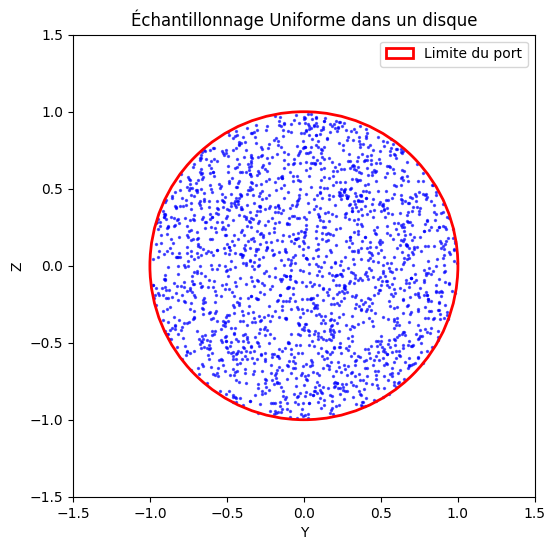

In [3]:
# 1. Définition de la distribution (Uniforme dans le carré [-1, 1])
dist_unif = lambda num_points: sp.stats.uniform.rvs(loc=-1.0, scale=2.0, size=(num_points, 2))

t1 = np.array([0., 1., 0.]) # axe Y
t2 = np.array([0., 0., 1.]) # axe Z
radius = 1.0

# 2. Appel corrigé avec les noms d'arguments
# On utilise l1 et l2 comme diamètres (2 * radius)
xs = sampler.sample_window(
    t1, 
    t2, 
    l1=2*radius, 
    l2=2*radius, 
    center=np.array([0., 0., 0.]), 
    num_points=2000, 
    dist=dist_unif
)

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(xs[:,1], xs[:,2], s=2, alpha=0.6, color='blue')

# Dessin du cercle limite (rayon = 1.0)
circle = plt.Circle((0, 0), radius, color='r', fill=False, linewidth=2, label="Limite du port")
ax.add_patch(circle)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

# J'ai corrigé le titre car ici c'est une loi Uniforme (Flat-top)
ax.set_title("Échantillonnage Uniforme dans un disque")
ax.set_xlabel("Y")
ax.set_ylabel("Z")
ax.legend()
plt.show()


## Chamber and target geometry parameters

In [4]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Define geometry and focal distances

### Define and create beams based on Omega 60 

In [5]:
df_omega = geometry.get_omega60_dataframe()

# Data verification
print(f"Generated columns: {df_omega.columns.tolist()}")
df_omega.head()

Generated columns: ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'center', 'normal', 't1', 't2', 'beam_radius', 'focus']


,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.203169,1.570796,blue,500.0,3.510000e-07,"[2.03859160948901e-17, 0.3329272751798081, 1.6...","[1.2355100663569759e-17, 0.20177410616958066, ...","[-1.0, 6.123233995736766e-17, 0.0]","[-5.99729184236327e-17, -0.9794320854860059, 0...",0.14,"[-2.059183443928331e-19, -0.003362901769493054..."
1,OMEGA_J02,0,0.203169,4.712389,blue,500.0,3.510000e-07,"[-6.11577482846703e-17, -0.3329272751798081, 1...","[-3.706530199070927e-17, -0.20177410616958066,...","[1.0, -1.8369701987210297e-16, 0.0]","[1.799187552708981e-16, 0.9794320854860059, 0....",0.14,"[6.177550331784993e-19, 0.003362901769493054, ..."
2,OMEGA_J03,0,0.545768,0.890581,blue,500.0,3.510000e-07,"[0.5386876470026672, 0.6658545503552404, 1.410...","[0.32647736181979836, 0.4035482123365094, 0.85...","[-0.7774375248306199, 0.6289601696333715, 0.0]","[-0.5375903897991704, -0.6644982658628751, 0.5...",0.14,"[-0.005441289363663393, -0.006725803538941921,..."
3,OMEGA_J04,0,0.545768,2.251011,blue,500.0,3.510000e-07,"[-0.5386876470026672, 0.6658545503552404, 1.41...","[-0.32647736181979836, 0.4035482123365094, 0.8...","[-0.7774375248306199, -0.6289601696333715, 0.0]","[0.5375903897991704, -0.6644982658628751, 0.51...",0.14,"[0.005441289363663393, -0.006725803538941921, ..."
4,OMEGA_J05,0,0.545768,4.032174,blue,500.0,3.510000e-07,"[-0.5386876470026675, -0.6658545503552403, 1.4...","[-0.3264773618197985, -0.40354821233650934, 0....","[0.7774375248306197, -0.6289601696333716, 0.0]","[0.5375903897991704, 0.6644982658628749, 0.519...",0.14,"[0.005441289363663393, 0.00672580353894181, -0..."


### Define focal point

In [6]:
# =====================================================
# Beam Focus Assignment Pipeline
# =====================================================

# 1. Generate the master configuration DataFrame
df_omega = geometry.get_omega60_dataframe()

# 2. Compute 3D focal points for all beams using a vectorized approach (Pandas apply)
# This replaces manual loops with a more robust and scalable implementation.
df_omega['focus'] = df_omega.apply(geometry.assign_beam_focus, axis=1)

# 3. Final verification of the focus coordinates
df_omega.head()

,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.203169,1.570796,blue,500.0,3.510000e-07,"[2.03859160948901e-17, 0.3329272751798081, 1.6...","[1.2355100663569759e-17, 0.20177410616958066, ...","[-1.0, 6.123233995736766e-17, 0.0]","[-5.99729184236327e-17, -0.9794320854860059, 0...",0.14,"[-2.059183443928331e-19, -0.003362901769493054..."
1,OMEGA_J02,0,0.203169,4.712389,blue,500.0,3.510000e-07,"[-6.11577482846703e-17, -0.3329272751798081, 1...","[-3.706530199070927e-17, -0.20177410616958066,...","[1.0, -1.8369701987210297e-16, 0.0]","[1.799187552708981e-16, 0.9794320854860059, 0....",0.14,"[6.177550331784993e-19, 0.003362901769493054, ..."
2,OMEGA_J03,0,0.545768,0.890581,blue,500.0,3.510000e-07,"[0.5386876470026672, 0.6658545503552404, 1.410...","[0.32647736181979836, 0.4035482123365094, 0.85...","[-0.7774375248306199, 0.6289601696333715, 0.0]","[-0.5375903897991704, -0.6644982658628751, 0.5...",0.14,"[-0.005441289363663393, -0.006725803538941921,..."
3,OMEGA_J04,0,0.545768,2.251011,blue,500.0,3.510000e-07,"[-0.5386876470026672, 0.6658545503552404, 1.41...","[-0.32647736181979836, 0.4035482123365094, 0.8...","[-0.7774375248306199, -0.6289601696333715, 0.0]","[0.5375903897991704, -0.6644982658628751, 0.51...",0.14,"[0.005441289363663393, -0.006725803538941921, ..."
4,OMEGA_J05,0,0.545768,4.032174,blue,500.0,3.510000e-07,"[-0.5386876470026675, -0.6658545503552403, 1.4...","[-0.3264773618197985, -0.40354821233650934, 0....","[0.7774375248306197, -0.6289601696333716, 0.0]","[0.5375903897991704, 0.6644982658628749, 0.519...",0.14,"[0.005441289363663393, 0.00672580353894181, -0..."


### Creates data frame of complete beam geometry and data

In [7]:
df_omega_final = sampler.get_final_beam_geometry(df_omega)

# 3. Affichage du résultat
print(f"Final OMEGA-60 table generated with {len(df_omega_final)} rows.")

# Visualisation des 10 premières lignes pour vérifier les colonnes _x, _y, _z
df_omega_final.head(10)

Final OMEGA-60 table generated with 60 rows.


,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,OMEGA_J01,0,0.203169,1.570796,blue,500.0,3.510000e-07,0.28,0.28,2.038592e-17,...,0.0,-5.997292e-17,-0.979432,0.201774,1.235510e-17,0.201774,0.979432,-2.059183e-19,-0.003363,-0.016324
1,OMEGA_J02,0,0.203169,4.712389,blue,500.0,3.510000e-07,0.28,0.28,-6.115775e-17,...,0.0,1.799188e-16,0.979432,0.201774,-3.706530e-17,-0.201774,0.979432,6.177550e-19,0.003363,-0.016324
2,OMEGA_J03,0,0.545768,0.890581,blue,500.0,3.510000e-07,0.28,0.28,5.386876e-01,...,0.0,-5.375904e-01,-0.664498,0.519075,3.264774e-01,0.403548,0.854729,-5.441289e-03,-0.006726,-0.014245
3,OMEGA_J04,0,0.545768,2.251011,blue,500.0,3.510000e-07,0.28,0.28,-5.386876e-01,...,0.0,5.375904e-01,-0.664498,0.519075,-3.264774e-01,0.403548,0.854729,5.441289e-03,-0.006726,-0.014245
4,OMEGA_J05,0,0.545768,4.032174,blue,500.0,3.510000e-07,0.28,0.28,-5.386876e-01,...,0.0,5.375904e-01,0.664498,0.519075,-3.264774e-01,-0.403548,0.854729,5.441289e-03,0.006726,-0.014245
5,OMEGA_J06,0,0.545768,5.392604,blue,500.0,3.510000e-07,0.28,0.28,5.386876e-01,...,0.0,-5.375904e-01,0.664498,0.519075,3.264774e-01,-0.403548,0.854729,-5.441289e-03,0.006726,-0.014245
6,OMEGA_J07,0,0.752437,0.299709,blue,500.0,3.510000e-07,0.28,0.28,1.077375e+00,...,0.0,-6.974829e-01,-0.215534,0.683420,6.529547e-01,0.201774,0.730026,-1.088258e-02,-0.003363,-0.012167
7,OMEGA_J08,0,0.752437,2.841884,blue,500.0,3.510000e-07,0.28,0.28,-1.077375e+00,...,0.0,6.974829e-01,-0.215534,0.683420,-6.529547e-01,0.201774,0.730026,1.088258e-02,-0.003363,-0.012167
8,OMEGA_J09,0,0.752437,3.441301,blue,500.0,3.510000e-07,0.28,0.28,-1.077375e+00,...,0.0,6.974829e-01,0.215534,0.683420,-6.529547e-01,-0.201774,0.730026,1.088258e-02,0.003363,-0.012167
9,OMEGA_J10,0,0.752437,5.983477,blue,500.0,3.510000e-07,0.28,0.28,1.077375e+00,...,0.0,-6.974829e-01,0.215534,0.683420,6.529547e-01,-0.201774,0.730026,-1.088258e-02,0.003363,-0.012167


## Impacts of the laser beams from window to a target sphere

## Simulation of impacts for 1 beam

### Simulation parameters

In [8]:
# 1. Prepare the row to match the format expected by beam_hit
row = df_omega.iloc[0].copy()

# Create the vectors that the beam_hit function will look for
row['l1'] = 0.28  # Diamètre standard OMEGA (mètres)
row['l2'] = 0.28
# 2. Now launch the function with this "prepared" row
impacts_1window = sampler.beam_hit(
    row, 
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

print(f"Effective impacts: {len(impacts_1window)} out of 10000 launched rays.")

Effective impacts: 10000 out of 10000 launched rays.


### Impacts data

In [9]:
impacts_1window.head()

,port,x,u,l,xsph,cs,sph,theta,phi,n
0,OMEGA_J01,"[-0.021117273447277117, 0.2945173784409992, 1....","[0.01266584193975808, -0.17866437897565904, -0...",1.649706,"[-0.00022236311147741036, -0.00022624749825189...",-0.895407,"[0.0010000000001023275, 0.3228045469616122, 3....",0.322805,3.935649,"[-0.2223631114546565, -0.2262474982287456, 0.9..."
1,OMEGA_J01,"[0.01412834479485118, 0.31786950729473734, 1.6...","[-0.008476341726483608, -0.19272432209060256, ...",1.649154,"[0.0001495508182583101, 3.739531584928679e-05,...",-0.977962,"[0.001000000000098876, 0.15477247825373527, 0....",0.154772,0.245027,"[0.14955081824352312, 0.03739531584558929, 0.9..."
2,OMEGA_J01,"[0.0010538901415526082, 0.34301132024631553, 1...","[-0.0006323218935138318, -0.20782052634703704,...",1.649038,"[1.1167421408601018e-05, 0.0003074114347165757...",-0.994630,"[0.001000000000133664, 0.3126846420796425, 1.5...",0.312685,1.534485,"[0.011167421407108337, 0.30741143467548593, 0...."
3,OMEGA_J01,"[-0.007916962381064992, 0.39700152961143703, 1...","[0.004746468860755698, -0.2400311148438367, -0...",1.650563,"[-8.26183342916443e-05, 0.0008151454206041242,...",-0.752619,"[0.001000000000417119, 0.9602267209901174, 1.6...",0.960227,1.671805,"[-0.08261833425718261, 0.8151454202641115, 0.5..."
4,OMEGA_J01,"[-0.03227125562013566, 0.327959514312982, 1.61...","[0.019359035075471598, -0.19875527465465462, -...",1.649378,"[-0.00034088598548458193, 0.000136905292520861...",-0.945159,"[0.0009999999999771914, 0.3761586300255851, 2....",0.376159,2.759694,"[-0.34088598549235705, 0.13690529252398398, 0...."


### Impacts of data organized

In [10]:
# 1. On prépare la ligne (correct)
row = df_omega.iloc[0].copy()
row['l1'] = 0.28  
row['l2'] = 0.28

# 2. ERREUR CORRIGÉE : On passe 'row' à la fonction, pas le tableau d'origine
df_impacts = sampler.beam_hit(
    row, # <-- C'est ici que ça changeait tout !
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

# Le reste fonctionnera tout seul
impact_1window_view = sampler.expand_impacts(df_impacts)
impact_1window_view.head(10)

,port,l,cs,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z,r,theta,phi
0,OMEGA_J01,1.649752,-0.888094,-0.019937,0.373512,1.607702,0.011958,-0.226039,-0.974045,-0.000210,0.000604,0.000769,-0.209842,0.603722,0.769081,0.001,0.693394,1.905314
1,OMEGA_J01,1.650041,-0.841948,0.017195,0.282807,1.626388,-0.010312,-0.171612,-0.985111,0.000180,-0.000360,0.000915,0.180453,-0.359710,0.915448,0.001,0.414176,5.177366
2,OMEGA_J01,1.649158,-0.977378,-0.009657,0.314496,1.619860,0.005794,-0.190700,-0.981631,-0.000102,0.000002,0.000995,-0.102222,0.001562,0.994760,0.001,0.102413,3.126311
3,OMEGA_J01,1.649078,-0.988914,0.005783,0.346323,1.613303,-0.003470,-0.209803,-0.977737,0.000061,0.000341,0.000938,0.061255,0.341158,0.938008,0.001,0.353959,1.393140
4,OMEGA_J01,1.649294,-0.957597,0.001165,0.304728,1.621872,-0.000699,-0.184827,-0.982771,0.000012,-0.000106,0.000994,0.012314,-0.105928,0.994298,0.001,0.106844,4.828119
5,OMEGA_J01,1.649300,-0.956708,-0.028765,0.328557,1.616963,0.017257,-0.199122,-0.979823,-0.000304,0.000146,0.000941,-0.304075,0.145790,0.941427,0.001,0.343960,2.694516
6,OMEGA_J01,1.649991,-0.850011,0.039986,0.299302,1.622990,-0.023980,-0.181508,-0.983097,0.000420,-0.000185,0.000889,0.419847,-0.184997,0.888541,0.001,0.476641,5.868152
7,OMEGA_J01,1.649205,-0.970590,-0.019236,0.347108,1.613141,0.011540,-0.210261,-0.977577,-0.000204,0.000345,0.000916,-0.203521,0.345157,0.916213,0.001,0.412272,2.103570
8,OMEGA_J01,1.649238,-0.965775,-0.021887,0.319289,1.618873,0.013131,-0.193568,-0.980999,-0.000232,0.000050,0.000972,-0.231501,0.049780,0.971560,0.001,0.239064,2.929786
9,OMEGA_J01,1.649046,-0.993407,0.007412,0.341493,1.614298,-0.004447,-0.206909,-0.978350,0.000079,0.000291,0.000953,0.078538,0.291041,0.953481,0.001,0.306215,1.307224


### Representation of the impact of one beam

### 

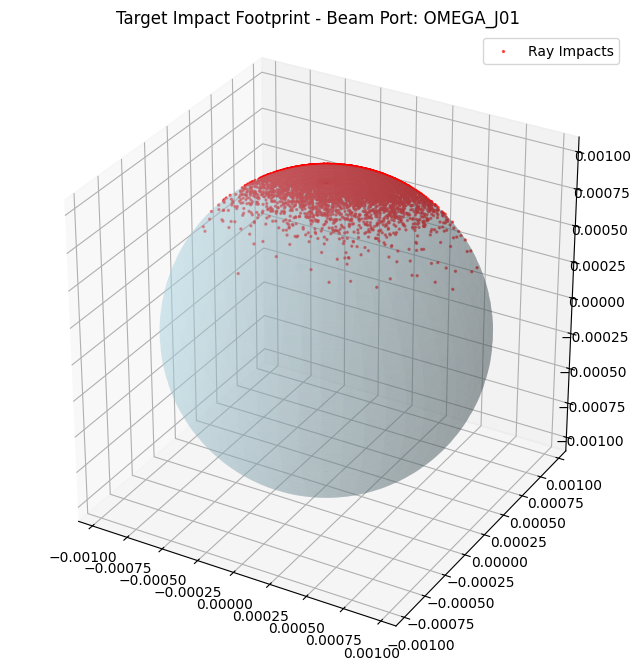

In [11]:
def plot_impact_footprint(impact_df, sphere_radius=TARGET_RADIUS):
    """
    Plots the 3D footprint of a single beam's rays on the target sphere.
    """
    # 1. Create 3D figure and axis
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 2. Draw the SOLID colored sphere (target)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    
    # Surface plot with transparency to see impacts on both sides
    ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                    color='lightblue', 
                    alpha=0.3,       # Transparency
                    linewidth=0, 
                    antialiased=True)

    # 3. Plot the impact points from the expanded DataFrame
    # Using the columns we just created: xsph_x, xsph_y, xsph_z
    xs = impact_df['xsph_x']
    ys = impact_df['xsph_y']
    zs = impact_df['xsph_z']
    
    # Scatter plot of the 10,000 rays (or as many as hit the target)
    ax.scatter(xs, ys, zs, color='red', s=2, alpha=0.6, label='Ray Impacts')

    # 4. Aesthetic configuration
    beam_id = impact_df['port'].iloc[0] if not impact_df.empty else "N/A"
    ax.set_title(f"Target Impact Footprint - Beam Port: {beam_id}")
    
    # Set axis limits to fit the sphere
    limit = sphere_radius * 1.1
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Set 1:1:1 aspect ratio so it looks like a sphere, not an egg
    ax.set_box_aspect([1, 1, 1])
    
    plt.legend()
    plt.show()


# 3. Maintenant tu peux appeler ta fonction de plot sans erreur
plot_impact_footprint(impact_1window_view, sphere_radius=TARGET_RADIUS)

## Simulation of hits from windows chosen by probability

### Simulation Monte Carlo of impacts

### Simulation parameters

In [12]:
# --- Execution ---
# On définit un nombre TOTAL de rayons pour l'ensemble des 60 faisceaux
# Si tu veux environ 1000 rayons par faisceau, mets 60000
N_TOTAL = 60000 

total_impact = sampler.impact_simulated(
    num_total_rays=N_TOTAL, # Nom de l'argument mis à jour
    target_radius=TARGET_RADIUS,
    target_center=np.array([0.0, 0.0, 0.0])
)

print(f"Simulation Monte-Carlo complétée.")
print(f"Total de rayons lancés : {N_TOTAL}")
print(f"Total d'impacts enregistrés sur la cible : {len(total_impact)}")


Simulation Monte-Carlo complétée.
Total de rayons lancés : 60000
Total d'impacts enregistrés sur la cible : 59999


### Information of impacts in dataframe

In [13]:
# --- Execution ---
df_impacts = sampler.preparar_dataframe_impacts(total_impact)
df_impacts

Valid impacts found: 59999


,port,subwindow,energy_weight,l,cs,theta,theta,phi,phi,x_x,...,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z
0,OMEGA_J01,unknown,0.4960,1.6496,-0.9168,0.4568,0.4568,2.8226,2.8226,-0.0397,...,1.6169,0.0238,-0.1992,-0.9797,-0.0004,0.0001,0.0009,-0.4188,0.1383,0.8975
1,OMEGA_J01,unknown,0.4960,1.6499,-0.8611,0.6515,0.6515,0.5736,0.5736,0.0485,...,1.6130,-0.0291,-0.2107,-0.9771,0.0005,0.0003,0.0008,0.5093,0.3291,0.7952
2,OMEGA_J01,unknown,0.4960,1.6493,-0.9503,0.3960,0.3960,2.5914,2.5914,-0.0311,...,1.6158,0.0187,-0.2024,-0.9791,-0.0003,0.0002,0.0009,-0.3288,0.2017,0.9226
3,OMEGA_J01,unknown,0.4960,1.6493,-0.9585,0.4343,0.4343,2.2699,2.2699,-0.0256,...,1.6135,0.0154,-0.2091,-0.9778,-0.0003,0.0003,0.0009,-0.2708,0.3221,0.9072
4,OMEGA_J01,unknown,0.4960,1.6490,-0.9971,0.2222,0.2222,1.1985,1.1985,0.0076,...,1.6160,-0.0045,-0.2020,-0.9794,0.0001,0.0002,0.0010,0.0802,0.2053,0.9754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59994,OMEGA_J60,unknown,0.4926,1.6492,-0.9649,2.8457,2.8457,3.5584,3.5584,-0.0252,...,-1.6175,0.0151,0.1974,0.9802,-0.0003,-0.0001,-0.0010,-0.2666,-0.1180,-0.9565
59995,OMEGA_J60,unknown,0.4926,1.6491,-0.9816,2.8585,2.8585,3.9038,3.9038,-0.0191,...,-1.6162,0.0114,0.2015,0.9794,-0.0002,-0.0002,-0.0010,-0.2021,-0.1929,-0.9602
59996,OMEGA_J60,unknown,0.4926,1.6490,-0.9985,2.9675,2.9675,4.4408,4.4408,-0.0044,...,-1.6167,0.0026,0.1998,0.9798,-0.0000,-0.0002,-0.0010,-0.0465,-0.1669,-0.9849
59997,OMEGA_J60,unknown,0.4926,1.6496,-0.9177,2.9108,2.9108,1.4074,1.4074,0.0035,...,-1.6241,-0.0021,0.1785,0.9839,0.0000,0.0002,-0.0010,0.0372,0.2257,-0.9735


### Pyvista (3D representation)

## Histogram of impacts in a 1m radius sphere

### Divides the sphere in sectors

In [14]:
class SphereSectors():
    def __init__(self, num_theta, num_phi):
      # Create the theta-phi grid edges
      self.theta_edges = np.linspace(0, np.pi, num_theta + 1)  # includes poles
      self.phi_edges = np.linspace(0, 2 * np.pi, num_phi + 1)  # includes closure

      # Coordinates of the spherical sector centers
      self.theta = 0.5 * (self.theta_edges[:-1] + self.theta_edges[1:])
      self.phi = 0.5 * (self.phi_edges[:-1] + self.phi_edges[1:])

      self.mtheta, self.mphi = np.meshgrid(self.theta, self.phi, indexing='ij')       

      return

sectors = SphereSectors( num_theta = 50, num_phi = 50)

### Representation of the mesh

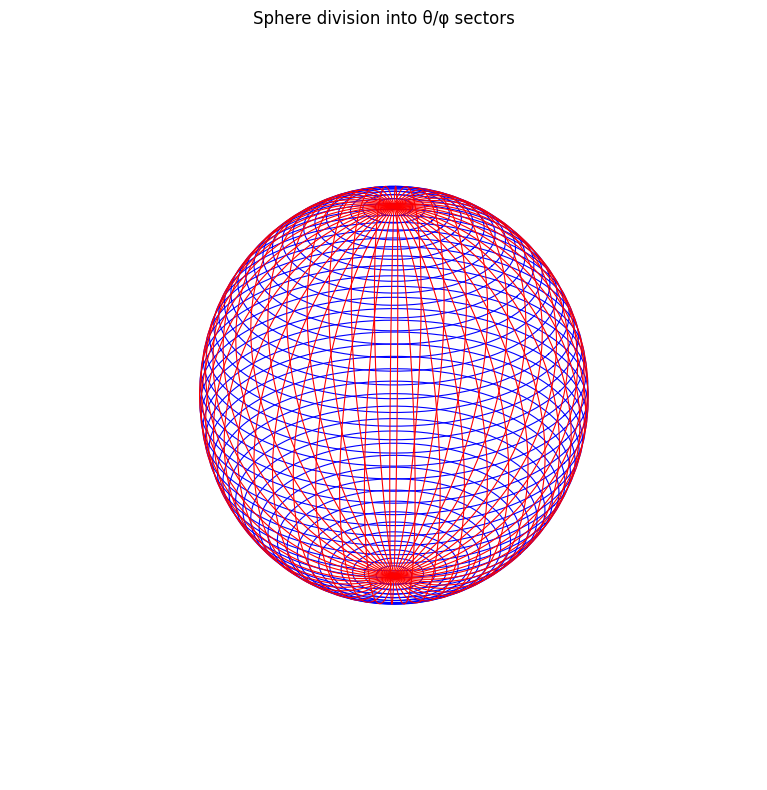

In [15]:
# Parameters
radius = TARGET_RADIUS

# Create 3D figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw horizontal lines (theta)
phi = np.linspace(0, 2 * np.pi, 200)
for theta in sectors.theta:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='blue', linewidth=0.8)

# Draw vertical lines (phi)
theta = np.linspace(0, np.pi, 200)
for phi in sectors.phi:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='red', linewidth=0.8)

# Aesthetics
ax.set_box_aspect([1, 1, 1])
ax.set_title("Sphere division into θ/φ sectors")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Function to calculate the area of sectors of the mesh

In [16]:
def spherical_sector_area( theta1, theta2, phi1, phi2, radius=1., ): #sij
    """
    Calculates the surface area of a spherical sector (a cell on the grid)
    defined by theta and phi boundaries.
    """
    # Calculate the area of the spherical zone (ring) between theta1 and theta2
    area_anillo = 2 * np.pi * radius**2 * np.abs(np.cos(theta1) - np.cos(theta2))
    
    # Calculate the longitudinal span
    delta_phi = np.abs(phi2 - phi1)
    
    # The sector area is the fraction of the ring corresponding to delta_phi
    area_sector = (delta_phi / (2 * np.pi)) * area_anillo
    return area_sector

# Calculate the area for all grid cells using broadcasting
sectors.area = spherical_sector_area( 
    sectors.theta_edges[:-1][:,None], 
    sectors.theta_edges[1:][:,None], 
    sectors.phi_edges[:-1][None,:], 
    sectors.phi_edges[1:][None,:], 
    radius=1. 
)

# Verification: the sum of all sector areas must equal the total sphere area (4*pi*r^2)
assert np.isclose( np.sum( sectors.area ), 4.*np.pi, atol=1e-4 ), "The calculated total area does not match the sphere's surface area."

### Plots the centers of each sector in the sphere mesh

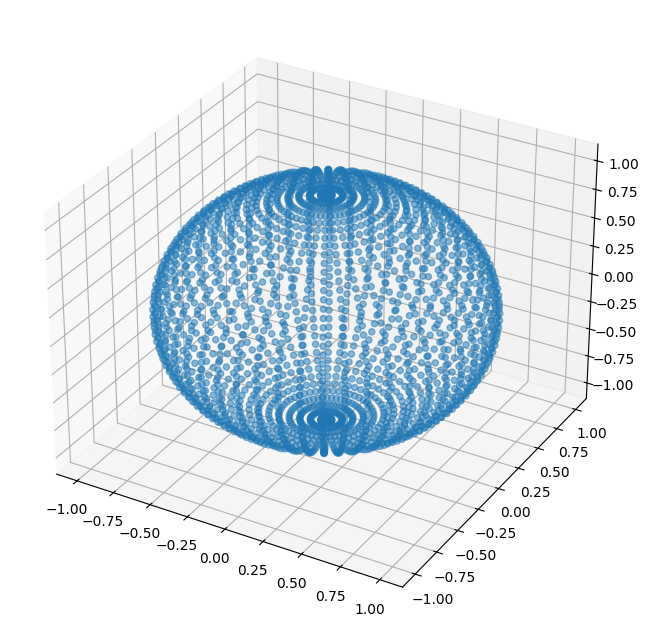

In [17]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = coord.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)
ax.scatter( xs, ys, zs, alpha=0.5)

### Creates energy histogram in sphere

In [18]:
def hist(hits, sectors):
    # 1. On force les données en 1D (format float standard)
    # .astype(float) et .values.ravel() garantissent que Numpy ne verra qu'une dimension
    theta = hits['theta'].astype(float).values.ravel()
    phi = hits['phi'].astype(float).values.ravel()
    weights = (hits['energy_weight'] * np.abs(hits['cs'])).astype(float).values.ravel()

    # 2. Histogramme 2D
    hs_raw, _, _ = np.histogram2d(
        theta,
        phi,
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=weights
    )

    # Densité par unité d'aire
    hs = hs_raw / sectors.area

    # 3. Validation de la conservation
    # On utilise les versions "plates" pour la somme aussi
    assert np.isclose(
        np.sum(hs * sectors.area),
        np.sum(weights),
        atol=1e-4
    ), "La somme pondérée ne correspond pas."

    # Normalisation et DataFrame final 
    hs_norm = (hs - np.min(hs)) / (np.max(hs) - np.min(hs))
    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist

In [19]:
hits = df_impacts[df_impacts['cs'] < 0]

In [20]:
# 1. On filtre et on fait une copie propre
hits = total_impact[total_impact['cs'] < 0].copy()

# 2. On s'assure que les colonnes sont des nombres (pas des objets/listes)
hits['theta'] = hits['theta'].astype(float)
hits['phi'] = hits['phi'].astype(float)
hits['energy_weight'] = hits['energy_weight'].astype(float)
hits['cs'] = hits['cs'].astype(float)

# 3. On applique le clip
hits['theta'] = np.clip(hits['theta'], 0, np.pi)
hits['phi'] = np.clip(hits['phi'], 0, 2*np.pi)

# 4. Maintenant le calcul passera sans problème
df_hist = hist(hits, sectors)

### Histogram graphic

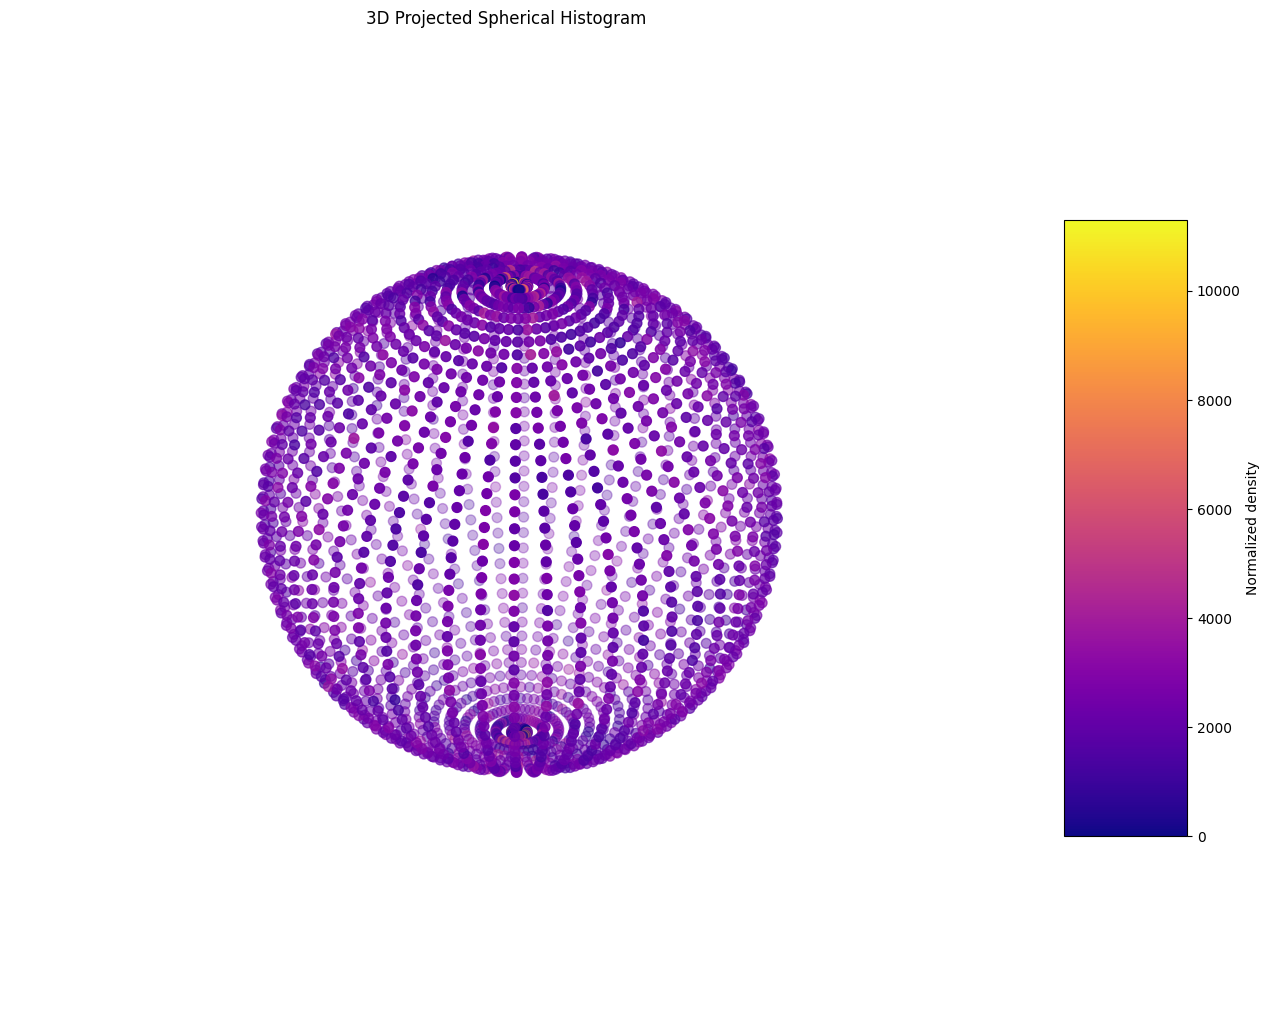

In [21]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
hs = df_hist['hs_density'].values

# Convert sector centers to Cartesian coordinates
xs, ys, zs = coord.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Flatten for scatter plot
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs should be the normalized histogram or density

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=50)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Normalized density")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Projected Spherical Histogram")
ax.set_axis_off()

plt.show()

### Pyvista histogram graphic

In [22]:
import nest_asyncio

# On applique le patch une seule fois au début
nest_asyncio.apply()

def plot_omega_histogram_pyvista(sectors, hs, target_radius=0.001, cmap='plasma', filename="simulation_omega60.html"):
    """
    Affiche l'histogramme sphérique d'énergie sur la cible et exporte en HTML.
    """
    # 1. Conversion des coordonnées
    display_radius = target_radius * 1.05 
    xs, ys, zs = coord.sph_to_cart(display_radius, sectors.mtheta, sectors.mphi)

    # 2. Préparation des données
    points = np.column_stack([xs.ravel(), ys.ravel(), zs.ravel()])
    densities = hs.ravel()

    # 3. Création des objets PyVista
    point_cloud = pv.PolyData(points)
    point_cloud["Irradiance"] = densities
    target_sphere = pv.Sphere(radius=target_radius, center=(0, 0, 0), theta_resolution=100, phi_resolution=100)

    # 4. Configuration du Plotter
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter(window_size=[800, 600])
    plotter.background_color = "white"

    # Ajout des éléments à la scène
    plotter.add_mesh(target_sphere, color="lightgrey", opacity=0.3, label="Cible")
    plotter.add_mesh(
        point_cloud,
        scalars="Irradiance",
        cmap=cmap,
        render_points_as_spheres=True,
        point_size=10, 
        show_scalar_bar=True,
        scalar_bar_args={"title": "Energie normalisée (J/mm2)"}
    )

    plotter.add_title("Distribution Sphérique de l'Energie - OMEGA-60")
    plotter.add_legend()
    plotter.view_isometric()

    # --- ÉTAPE CRUCIALE : EXPORT AVANT LE SHOW ---
    # On utilise l'argument 'filename' passé à la fonction
    plotter.export_html(filename) 
    print(f"Fichier interactif sauvegardé : {filename}")

    # Affichage dans le Notebook
    plotter.show()

# --- UTILISATION ---
plot_omega_histogram_pyvista(sectors, hs, target_radius=TARGET_RADIUS, cmap='plasma', filename="simulation_omega60.html")

Fichier interactif sauvegardé : simulation_omega60.html


Widget(value='<iframe src="http://localhost:53252/index.html?ui=P_0x19e253d39d0_0&reconnect=auto" class="pyvis…

### Normalization to compare different simulations

In [23]:
def hist_normalized_intensity(hits, sectors):
    # 1. On force les données en 1D (format float standard)
    # .astype(float) et .values.ravel() garantissent que Numpy ne verra qu'une dimension
    theta = hits['theta'].astype(float).values.ravel()
    phi = hits['phi'].astype(float).values.ravel()
    weights = (hits['energy_weight'] * np.abs(hits['cs'])).astype(float).values.ravel()

    # 2. Histogramme 2D
    hs_raw, _, _ = np.histogram2d(
        theta,
        phi,
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=weights
    )

    # Intensité 
    hs = hs_raw / sectors.area

    total_energy= np.sum(hs * sectors.area)

    # Normalisation et DataFrame final 
    hs_norm = hs/total_energy

    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist

In [24]:
hits = df_impacts[df_impacts['cs'] < 0]

In [25]:
# 1. On filtre et on fait une copie propre
hits = total_impact[total_impact['cs'] < 0].copy()

# 2. On s'assure que les colonnes sont des nombres (pas des objets/listes)
hits['theta'] = hits['theta'].astype(float)
hits['phi'] = hits['phi'].astype(float)
hits['energy_weight'] = hits['energy_weight'].astype(float)
hits['cs'] = hits['cs'].astype(float)

# 3. On applique le clip
hits['theta'] = np.clip(hits['theta'], 0, np.pi)
hits['phi'] = np.clip(hits['phi'], 0, 2*np.pi)

# 4. Maintenant le calcul passera sans problème
df_hist_norm = hist_normalized_intensity(hits, sectors)

### Histogramm with normalized intensity

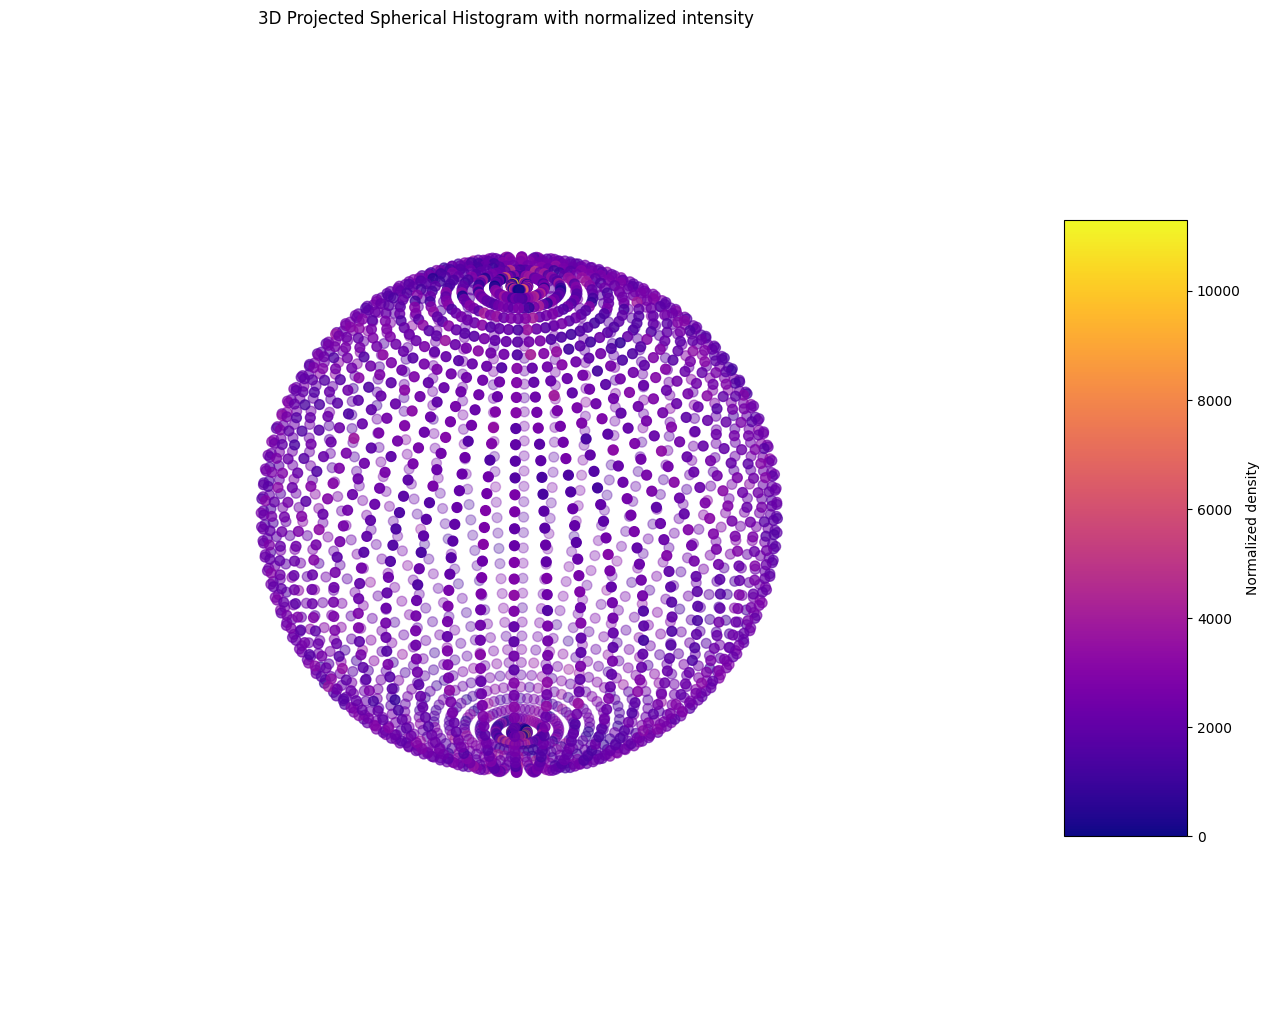

In [26]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
hs = df_hist_norm['hs_density'].values

# Convert sector centers to Cartesian coordinates
xs, ys, zs = coord.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Flatten for scatter plot
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs should be the normalized histogram or density

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=50)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Normalized density")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Projected Spherical Histogram with normalized intensity")
ax.set_axis_off()

plt.show()

### Integration in phi to obtain the distribution in theta for the ARWEN simulation

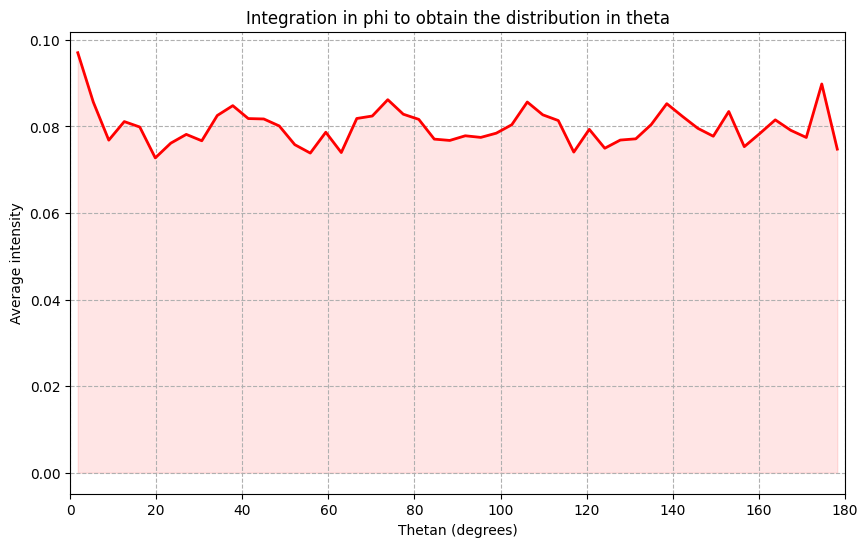

In [27]:
def compute_theta_distribution(df_hist_norm):
    """
    Integers I(theta,phi) on phi to obtain I(theta)
    """
    # 1. On regroupe par valeur de theta et on fait la moyenne des densités
    # On utilise 'hs_unit' (ta nouvelle normalisation physique)
    theta_profile = df_hist_norm.groupby('theta')['hs_norm'].mean().reset_index()
    
    # 2. Renommer pour plus de clarté
    theta_profile.columns = ['theta_rad', 'intensity_avg']
    
    # 3. Conversion en degrés pour faciliter la lecture du graphique
    theta_profile['theta_deg'] = np.degrees(theta_profile['theta_rad'])
    
    return theta_profile

# --- EXÉCUTION ---
# On récupère le profil 1D
df_theta = compute_theta_distribution(df_hist_norm)

# --- VISUALISATION ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_theta['theta_deg'], df_theta['intensity_avg'], color='red', lw=2)
plt.fill_between(df_theta['theta_deg'], df_theta['intensity_avg'], color='red', alpha=0.1)

plt.title("Integration in phi to obtain the distribution in theta")
plt.xlabel("Thetan (degrees)")
plt.ylabel("Average intensity")
plt.grid(True, linestyle='--')
plt.xlim(0, 180)
plt.show()

In [29]:
%pip install tables

from helpers import utils
utils.write(df_hist_norm, filename="histograma_muestreo.h5")

  Using cached tables-3.11.1-cp311-abi3-win_amd64.whl.metadata (2.1 kB)
  Using cached numexpr-2.14.1-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached blosc2-4.1.2-cp311-cp311-win_amd64.whl.metadata (6.2 kB)
  Using cached ndindex-1.10.1-cp311-cp311-win_amd64.whl.metadata (3.7 kB)
Using cached tables-3.11.1-cp311-abi3-win_amd64.whl (6.5 MB)
Using cached blosc2-4.1.2-cp311-cp311-win_amd64.whl (3.1 MB)
Using cached numexpr-2.14.1-cp311-cp311-win_amd64.whl (160 kB)
Using cached py_cpuinfo-9.0.0-py3-none-any.whl (22 kB)
Using cached ndindex-1.10.1-cp311-cp311-win_amd64.whl (157 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\clara\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
